In [8]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')  # Ensure non-interactive backend
import matplotlib.pyplot as plt
plt.switch_backend('Agg')  # In case only plt is used

import seaborn as sns

# For inline plotting on Kaggle
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

sns.set(style='whitegrid', context='notebook')

In [13]:
# Load the dataset
data_file = ('ocean_plastic_pollution_data.csv')
df = pd.read_csv(data_file, encoding='ascii', delimiter=',')

# Display the first few rows
print('Head of the dataframe:')
print(df.head())

# Display dataframe info and summary statistics
print('\nDataframe info:')
print(df.info())

print('\nSummary Statistics:')
print(df.describe(include='all'))

Head of the dataframe:
              Date          Region   Latitude   Longitude  \
0  01/01/2015 0:00    Arctic Ocean -58.459627 -169.626456   
1  01/01/2015 1:00  Southern Ocean  49.449892   77.319852   
2  01/01/2015 2:00    Indian Ocean  80.422411  130.332581   
3  01/01/2015 3:00  Southern Ocean -71.920725   58.003563   
4  01/01/2015 4:00  Southern Ocean -61.993742 -169.011282   

                       Plastic_Type  Plastic_Weight_kg  Depth_meters  
0  Polyethylene Terephthalate (PET)              41.93         73.09  
1                 Polyethylene (PE)             403.38         71.21  
2  Polyethylene Terephthalate (PET)             241.70         19.53  
3  Polyethylene Terephthalate (PET)             482.76         69.72  
4  Polyethylene Terephthalate (PET)              58.75         58.14  

Dataframe info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------

In [11]:
# Convert 'Date' column to datetime. The date might be in various formats, so errors='coerce' ensures invalid formats are set as NaT.
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# It might be useful to extract additional temporal features if the date conversion is successful
if df['Date'].notnull().sum() > 0:
    df['Year'] = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month
    df['Day'] = df['Date'].dt.day
    print('Date conversion and feature extraction successful.')
else:
    print('Date conversion failed for all rows. Please check the format of the Date column.')

# Check for missing values
print('\nMissing values in each column:')
print(df.isnull().sum())

# For simplicity, drop rows with missing values.
df.dropna(inplace=True)
print('\nDataframe shape after dropping missing values:', df.shape)

Date conversion and feature extraction successful.

Missing values in each column:
Date                 8952
Region                  0
Latitude                0
Longitude               0
Plastic_Type            0
Plastic_Weight_kg       0
Depth_meters            0
Year                 8952
Month                8952
Day                  8952
dtype: int64

Dataframe shape after dropping missing values: (6048, 10)


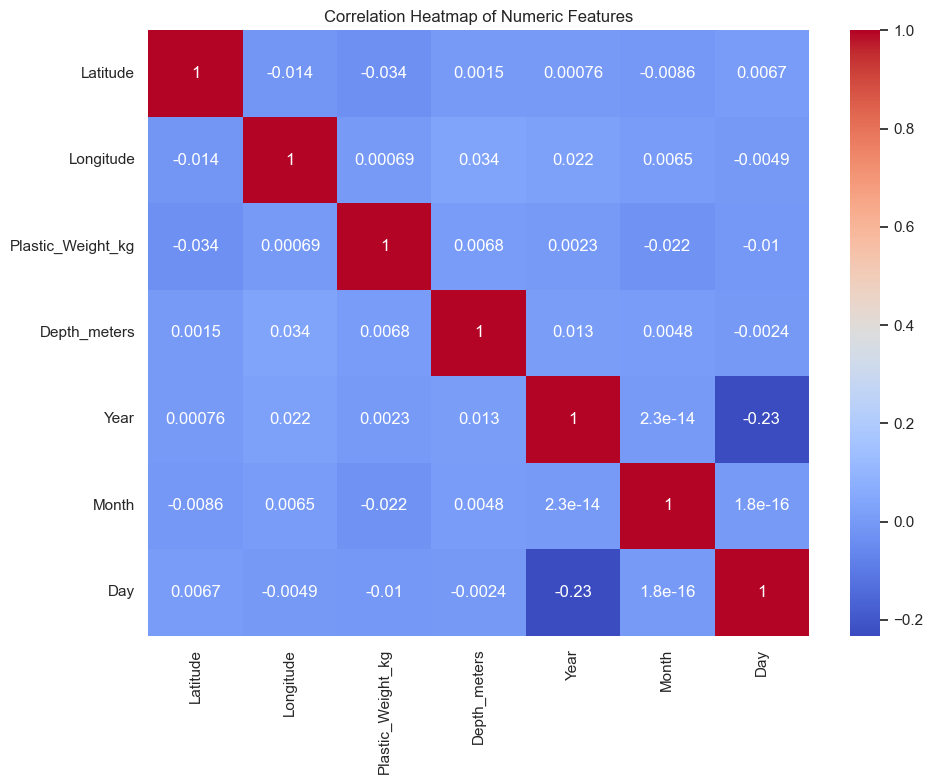

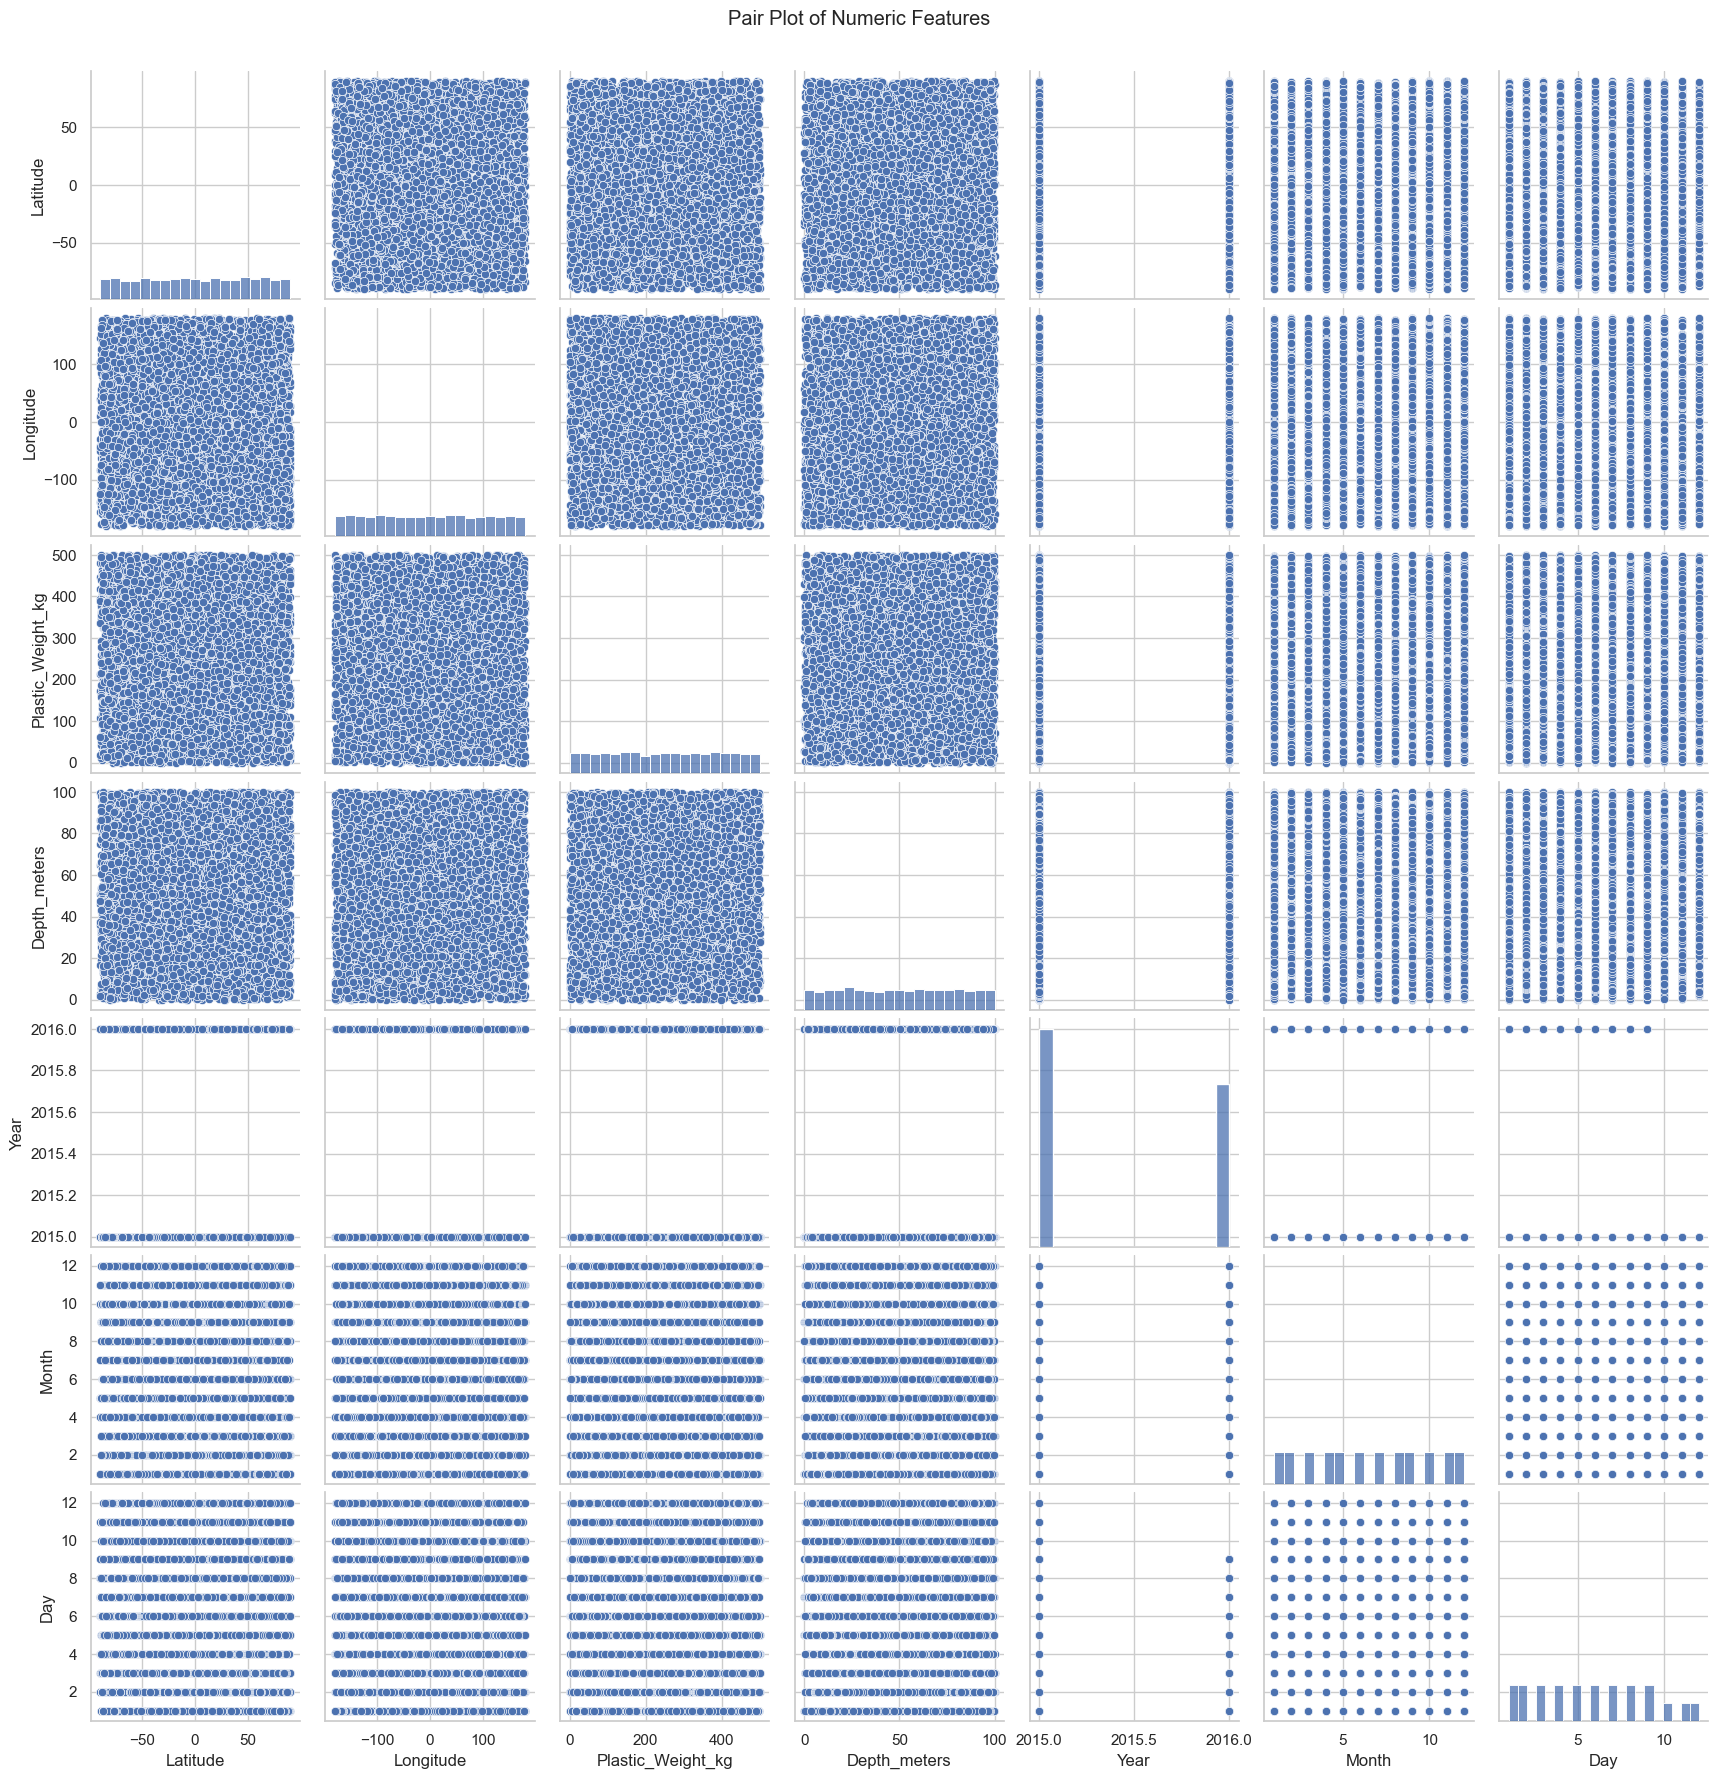

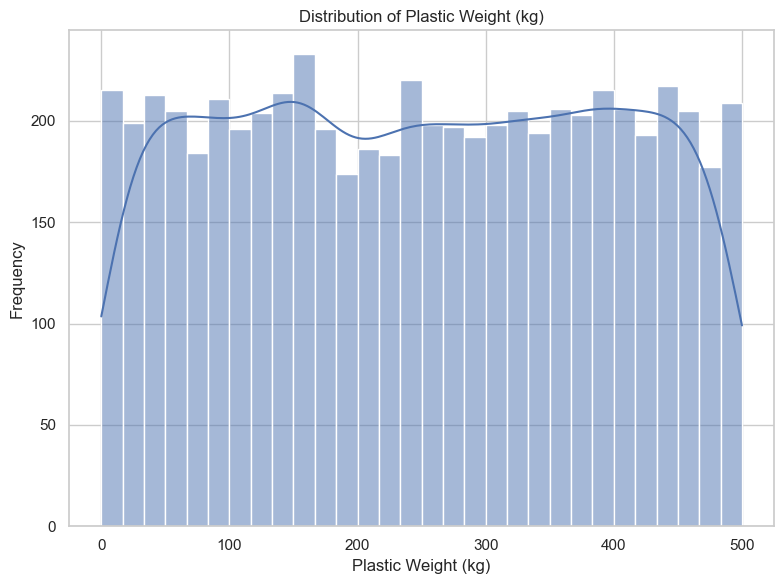

In [12]:
# Generate a correlation heatmap if there are four or more numeric columns
numeric_df = df.select_dtypes(include=[np.number])
if numeric_df.shape[1] >= 4:
    plt.figure(figsize=(10, 8))
    corr = numeric_df.corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm')
    plt.title('Correlation Heatmap of Numeric Features')
    plt.tight_layout()
    plt.show()
else:
    print('Not enough numeric columns for a correlation heatmap')

# Pair Plot of the numeric features to inspect relationships
sns.pairplot(numeric_df)
plt.suptitle('Pair Plot of Numeric Features', y=1.02)
plt.show()

# Histogram for Plastic_Weight_kg to inspect its distribution
plt.figure(figsize=(8, 6))
sns.histplot(df['Plastic_Weight_kg'], kde=True, bins=30)
plt.title('Distribution of Plastic Weight (kg)')
plt.xlabel('Plastic Weight (kg)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

Features used for prediction: ['Latitude', 'Longitude', 'Depth_meters', 'Region_Code', 'Plastic_Type_Code']
R2 Score: -0.0025


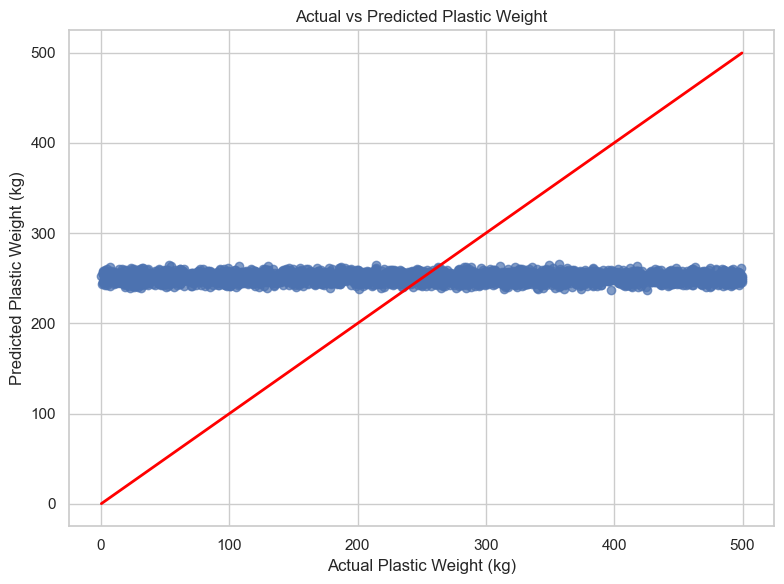

In [14]:
# Prepare data for regression: Predict Plastic_Weight_kg using selected features
feature_cols = ['Latitude', 'Longitude', 'Depth_meters']

# If the temporal features were extracted, consider including the Year
if 'Year' in df.columns:
    feature_cols.append('Year')

# Also include Region and Plastic_Type by converting them to categorical codes
if 'Region' in df.columns:
    df['Region_Code'] = df['Region'].astype('category').cat.codes
    feature_cols.append('Region_Code')

if 'Plastic_Type' in df.columns:
    df['Plastic_Type_Code'] = df['Plastic_Type'].astype('category').cat.codes
    feature_cols.append('Plastic_Type_Code')

print('Features used for prediction:', feature_cols)

X = df[feature_cols]
y = df['Plastic_Weight_kg']

# Split the data into training and testing sets (80:20 ratio)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit a simple Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Evaluate the model using R2 score
r2 = r2_score(y_test, y_pred)
print(f'R2 Score: {r2:.4f}')

# Plotting Actual vs Predicted values
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel('Actual Plastic Weight (kg)')
plt.ylabel('Predicted Plastic Weight (kg)')
plt.title('Actual vs Predicted Plastic Weight')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)  # Identity line
plt.tight_layout()
plt.show()